   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

S

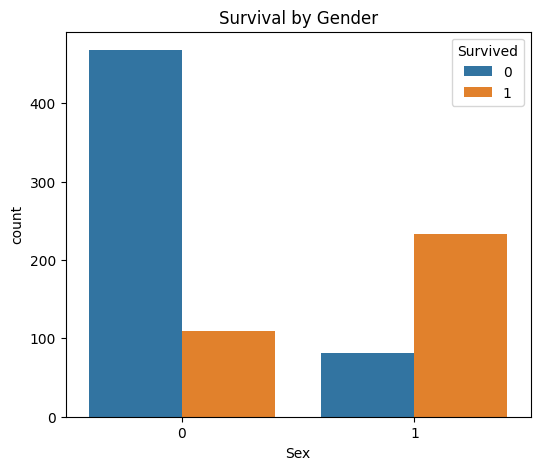

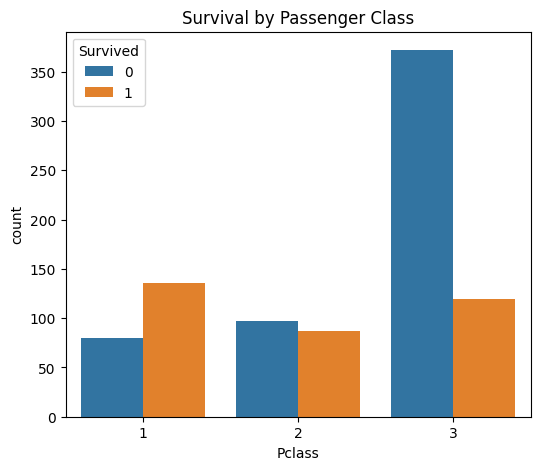

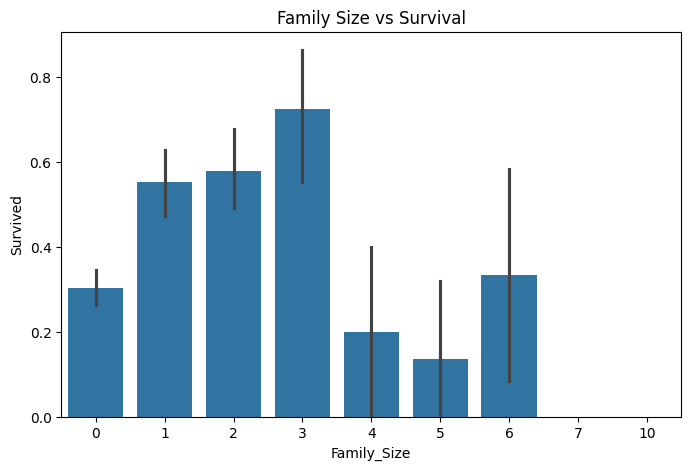


Survival Rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Pivot Table:
Pclass         1         2         3
Sex                                 
0       0.368852  0.157407  0.135447
1       0.968085  0.921053  0.500000

Dataset Saved Successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print(df.head())

# Dataset Info
print("\nShape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# Handle Missing Values
df["Age"] = df["Age"].fillna(df["Age"].mean())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df.drop("Cabin", axis=1)

# Convert Text to Numbers
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

# Survival by Gender
plt.figure(figsize=(6,5))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title("Survival by Gender")

plt.savefig("gender_survival.png")

plt.show()

# Survival by Passenger Class
plt.figure(figsize=(6,5))

sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df
)

plt.title("Survival by Passenger Class")

plt.savefig("class_survival.png")

plt.show()

# Family Size Analysis
df["Family_Size"] = df["SibSp"] + df["Parch"]

plt.figure(figsize=(8,5))

sns.barplot(
    x="Family_Size",
    y="Survived",
    data=df
)

plt.title("Family Size vs Survival")

plt.savefig("family_survival.png")

plt.show()

# GroupBy Analysis
print("\nSurvival Rate by Passenger Class:")

print(df.groupby("Pclass")["Survived"].mean())

# Pivot Table
pivot = pd.pivot_table(
    df,
    values="Survived",
    index="Sex",
    columns="Pclass"
)

print("\nPivot Table:")
print(pivot)

# Export Cleaned Dataset
df.to_csv(
    "cleaned_titanic.csv",
    index=False
)

print("\nDataset Saved Successfully!")